In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

## Loading Dataset

In [3]:
df=pd.read_csv("C:\\Users\\shiva\\OneDrive\\Desktop\\Healthcare Data Analysis\\Data\\healthcare_dataset.csv")
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


### Understanding Dataset

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 6.4

In [6]:
df.columns

Index(['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition',
       'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider',
       'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date',
       'Medication', 'Test Results'],
      dtype='object')

In [7]:
df.describe()

,Age,Billing Amount,Room Number
count,55500.000000,55500.000000,55500.000000
mean,51.539459,25539.316097,301.134829
std,19.602454,14211.454431,115.243069
min,13.000000,-2008.492140,101.000000
25%,35.000000,13241.224652,202.000000
50%,52.000000,25538.069376,302.000000
75%,68.000000,37820.508436,401.000000
max,89.000000,52764.276736,500.000000


In [8]:
df.isnull().sum()

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

In [28]:
df1=df.drop_duplicates().copy()
df1

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55495,eLIZABeTH jaCkSOn,42,Female,O+,Asthma,2020-08-16,Joshua Jarvis,Jones-Thompson,Blue Cross,2650.714952,417,Elective,2020-09-15,Penicillin,Abnormal
55496,KYle pEREz,61,Female,AB-,Obesity,2020-01-23,Taylor Sullivan,Tucker-Moyer,Cigna,31457.797307,316,Elective,2020-02-01,Aspirin,Normal
55497,HEATher WaNG,38,Female,B+,Hypertension,2020-07-13,Joe Jacobs DVM,"and Mahoney Johnson Vasquez,",UnitedHealthcare,27620.764717,347,Urgent,2020-08-10,Ibuprofen,Abnormal
55498,JENniFER JOneS,43,Male,O-,Arthritis,2019-05-25,Kimberly Curry,"Jackson Todd and Castro,",Medicare,32451.092358,321,Elective,2019-05-31,Ibuprofen,Abnormal


### Date columns to correct format

In [29]:
df1.loc[:,'Date of Admission'] = pd.to_datetime(df1['Date of Admission'], errors='coerce')
df1.loc[:,'Discharge Date'] = pd.to_datetime(df1['Discharge Date'], errors='coerce')
df1.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31 00:00:00,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02 00:00:00,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20 00:00:00,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26 00:00:00,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22 00:00:00,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07 00:00:00,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18 00:00:00,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18 00:00:00,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19 00:00:00,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09 00:00:00,Penicillin,Abnormal


## clean text columns

In [30]:
df1['Name']=df1['Name'].str.strip().str.title()
df1['Doctor']=df1['Doctor'].str.strip().str.title()
df1['Medication'] = df1['Medication'].str.strip().str.title()
df1['Medical Condition']=df1['Medical Condition'].str.strip().str.title()
df1['Gender']=df1['Gender'].str.strip().str.title()
df1['Hospital']=df1['Hospital'].str.strip().str.title()
df1.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby Jackson,30,Male,B-,Cancer,2024-01-31 00:00:00,Matthew Smith,Sons And Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02 00:00:00,Paracetamol,Normal
1,Leslie Terry,62,Male,A+,Obesity,2019-08-20 00:00:00,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26 00:00:00,Ibuprofen,Inconclusive
2,Danny Smith,76,Female,A-,Obesity,2022-09-22 00:00:00,Tiffany Mitchell,Cook Plc,Aetna,27955.096079,205,Emergency,2022-10-07 00:00:00,Aspirin,Normal
3,Andrew Watts,28,Female,O+,Diabetes,2020-11-18 00:00:00,Kevin Wells,"Hernandez Rogers And Vang,",Medicare,37909.782410,450,Elective,2020-12-18 00:00:00,Ibuprofen,Abnormal
4,Adrienne Bell,43,Female,AB+,Cancer,2022-09-19 00:00:00,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09 00:00:00,Penicillin,Abnormal


## Create New columns

In [38]:

df1['Discharge Date'] = pd.to_datetime(df1['Discharge Date'])
df1['Date of Admission'] = pd.to_datetime(df1['Date of Admission'])

df1['Stay Duration']= (df1['Discharge Date'] - df1['Date of Admission']).dt.days
df1.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Age_Group,Stay Duration
0,Bobby Jackson,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons And Miller,Blue Cross,18856.28,328,Urgent,2024-02-02,Paracetamol,Normal,Young Adult,2
1,Leslie Terry,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.33,265,Emergency,2019-08-26,Ibuprofen,Inconclusive,Middle Aged,6
2,Danny Smith,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook Plc,Aetna,27955.10,205,Emergency,2022-10-07,Aspirin,Normal,Senior,15
3,Andrew Watts,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers And Vang,",Medicare,37909.78,450,Elective,2020-12-18,Ibuprofen,Abnormal,Young Adult,30
4,Adrienne Bell,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.32,458,Urgent,2022-10-09,Penicillin,Abnormal,Adult,20


In [39]:
df1['Admission_Month'] = df1['Date of Admission'].dt.month_name()
df1['Admission_Year']  = df1['Date of Admission'].dt.year
df1['Weekday']  = df1['Date of Admission'].dt.day_name()
df1.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Age_Group,Stay Duration,Admission_Month,Admission_Year,Weekday
0,Bobby Jackson,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons And Miller,Blue Cross,18856.28,328,Urgent,2024-02-02,Paracetamol,Normal,Young Adult,2,January,2024,Wednesday
1,Leslie Terry,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.33,265,Emergency,2019-08-26,Ibuprofen,Inconclusive,Middle Aged,6,August,2019,Tuesday
2,Danny Smith,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook Plc,Aetna,27955.10,205,Emergency,2022-10-07,Aspirin,Normal,Senior,15,September,2022,Thursday
3,Andrew Watts,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers And Vang,",Medicare,37909.78,450,Elective,2020-12-18,Ibuprofen,Abnormal,Young Adult,30,November,2020,Wednesday
4,Adrienne Bell,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.32,458,Urgent,2022-10-09,Penicillin,Abnormal,Adult,20,September,2022,Monday


In [40]:
bins = [0, 12, 18, 35, 50, 65, 100]
labels = ['Child', 'Teen', 'Young Adult', 'Adult', 'Middle Aged', 'Senior']
df1['Age_Group'] = pd.cut(df1['Age'], bins=bins, labels=labels)
df1.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Age_Group,Stay Duration,Admission_Month,Admission_Year,Weekday
0,Bobby Jackson,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons And Miller,Blue Cross,18856.28,328,Urgent,2024-02-02,Paracetamol,Normal,Young Adult,2,January,2024,Wednesday
1,Leslie Terry,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.33,265,Emergency,2019-08-26,Ibuprofen,Inconclusive,Middle Aged,6,August,2019,Tuesday
2,Danny Smith,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook Plc,Aetna,27955.10,205,Emergency,2022-10-07,Aspirin,Normal,Senior,15,September,2022,Thursday
3,Andrew Watts,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers And Vang,",Medicare,37909.78,450,Elective,2020-12-18,Ibuprofen,Abnormal,Young Adult,30,November,2020,Wednesday
4,Adrienne Bell,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.32,458,Urgent,2022-10-09,Penicillin,Abnormal,Adult,20,September,2022,Monday


In [42]:
df1['Billing Amount']=df1['Billing Amount'].round(2)  # round 2 for 2 decimal places 
df1.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Age_Group,Stay Duration,Admission_Month,Admission_Year,Weekday
0,Bobby Jackson,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons And Miller,Blue Cross,18856.28,328,Urgent,2024-02-02,Paracetamol,Normal,Young Adult,2,January,2024,Wednesday
1,Leslie Terry,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.33,265,Emergency,2019-08-26,Ibuprofen,Inconclusive,Middle Aged,6,August,2019,Tuesday
2,Danny Smith,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook Plc,Aetna,27955.10,205,Emergency,2022-10-07,Aspirin,Normal,Senior,15,September,2022,Thursday
3,Andrew Watts,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers And Vang,",Medicare,37909.78,450,Elective,2020-12-18,Ibuprofen,Abnormal,Young Adult,30,November,2020,Wednesday
4,Adrienne Bell,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.32,458,Urgent,2022-10-09,Penicillin,Abnormal,Adult,20,September,2022,Monday


In [43]:
df1['Cost Per Day']= (df1['Billing Amount'] / df1['Stay Duration']).astype(float).round(2)
df1

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,...,Admission Type,Discharge Date,Medication,Test Results,Age_Group,Stay Duration,Admission_Month,Admission_Year,Weekday,Cost Per Day
0,Bobby Jackson,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons And Miller,Blue Cross,18856.28,...,Urgent,2024-02-02,Paracetamol,Normal,Young Adult,2,January,2024,Wednesday,9428.14
1,Leslie Terry,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.33,...,Emergency,2019-08-26,Ibuprofen,Inconclusive,Middle Aged,6,August,2019,Tuesday,5607.22
2,Danny Smith,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook Plc,Aetna,27955.10,...,Emergency,2022-10-07,Aspirin,Normal,Senior,15,September,2022,Thursday,1863.67
3,Andrew Watts,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers And Vang,",Medicare,37909.78,...,Elective,2020-12-18,Ibuprofen,Abnormal,Young Adult,30,November,2020,Wednesday,1263.66
4,Adrienne Bell,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.32,...,Urgent,2022-10-09,Penicillin,Abnormal,Adult,20,September,2022,Monday,711.92
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55495,Elizabeth Jackson,42,Female,O+,Asthma,2020-08-16,Joshua Jarvis,Jones-Thompson,Blue Cross,2650.71,...,Elective,2020-09-15,Penicillin,Abnormal,Adult,30,August,2020,Sunday,88.36
55496,Kyle Perez,61,Female,AB-,Obesity,2020-01-23,Taylor Sullivan,Tucker-Moyer,Cigna,31457.80,...,Elective,2020-02-01,Aspirin,Normal,Middle Aged,9,January,2020,Thursday,3495.31
55497,Heather Wang,38,Female,B+,Hypertension,2020-07-13,Joe Jacobs Dvm,"And Mahoney Johnson Vasquez,",UnitedHealthcare,27620.76,...,Urgent,2020-08-10,Ibuprofen,Abnormal,Adult,28,July,2020,Monday,986.46
55498,Jennifer Jones,43,Male,O-,Arthritis,2019-05-25,Kimberly Curry,"Jackson Todd And Castro,",Medicare,32451.09,...,Elective,2019-05-31,Ibuprofen,Abnormal,Adult,6,May,2019,Saturday,5408.52


In [56]:
df1['Medical Condition'].value_counts()


Medical Condition
Arthritis       9218
Diabetes        9216
Hypertension    9151
Obesity         9146
Cancer          9140
Asthma          9095
Name: count, dtype: int64

## Graphs 

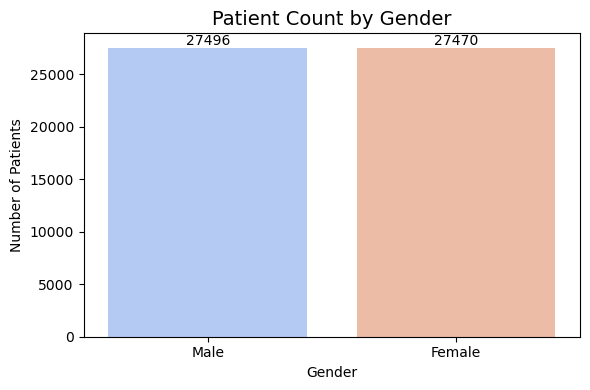

In [68]:
plt.figure(figsize=(6,4))
ax = sns.countplot(
    x='Gender',
    hue='Gender',         
    data=df1,
    palette='coolwarm',
    legend=False             )
plt.title("Patient Count by Gender", fontsize=14)
plt.xlabel("Gender")
plt.ylabel("Number of Patients")

for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', fontsize=10)
plt.tight_layout()
plt.show()

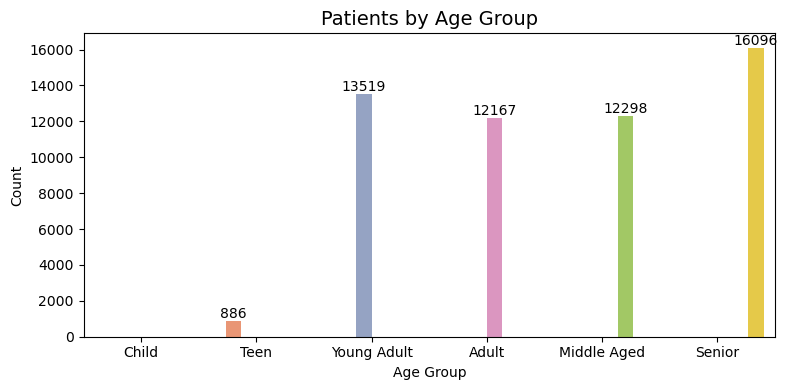

In [72]:
plt.figure(figsize=(8,4))
ax = sns.countplot(
    data=df1,
    x='Age_Group',
    hue='Age_Group',      
    palette='Set2',
    legend=False
)
plt.title("Patients by Age Group", fontsize=14)
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge')
plt.tight_layout()
plt.show()

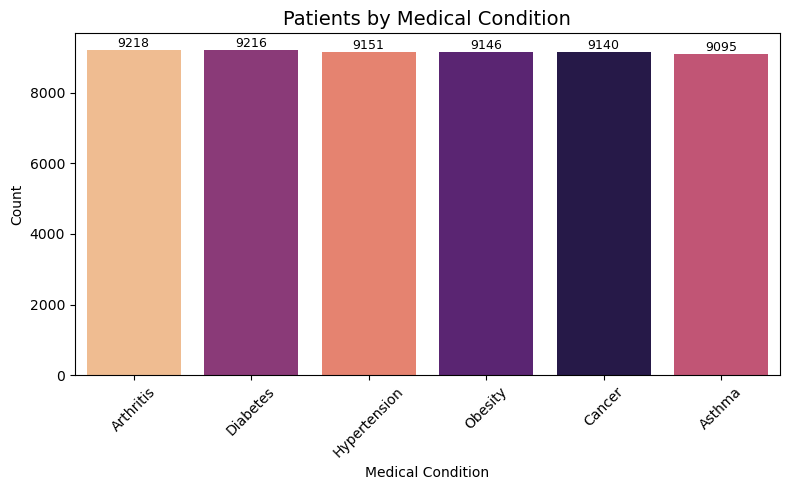

In [74]:
plt.figure(figsize=(8,5))
ax = sns.countplot(
    data=df1,
    x='Medical Condition',
    hue='Medical Condition',  
    order=df1['Medical Condition'].value_counts().index,
    palette='magma',
    legend=False             
)
plt.title("Patients by Medical Condition", fontsize=14)
plt.xlabel("Medical Condition")
plt.ylabel("Count")
plt.xticks(rotation=45)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', fontsize=9)
plt.tight_layout()
plt.show()

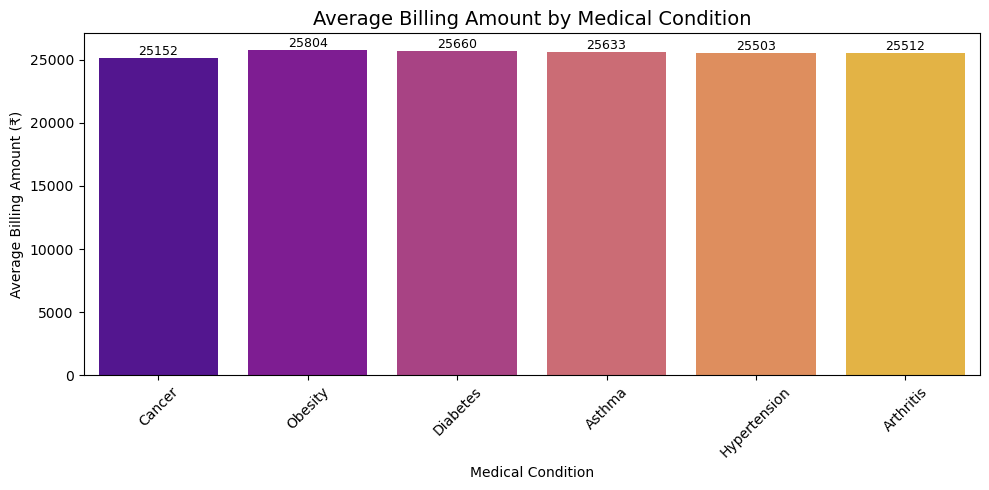

In [75]:
avg_billing = df1.groupby('Medical Condition')['Billing Amount'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
ax = sns.barplot(
    data=df1,
    x='Medical Condition',
    y='Billing Amount',
    hue='Medical Condition',  
    palette='plasma',
    errorbar=None,            
    legend=False               
)
plt.title("Average Billing Amount by Medical Condition", fontsize=14)
plt.xlabel("Medical Condition")
plt.ylabel("Average Billing Amount (₹)")
plt.xticks(rotation=45)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', label_type='edge', fontsize=9)
plt.tight_layout()
plt.show()

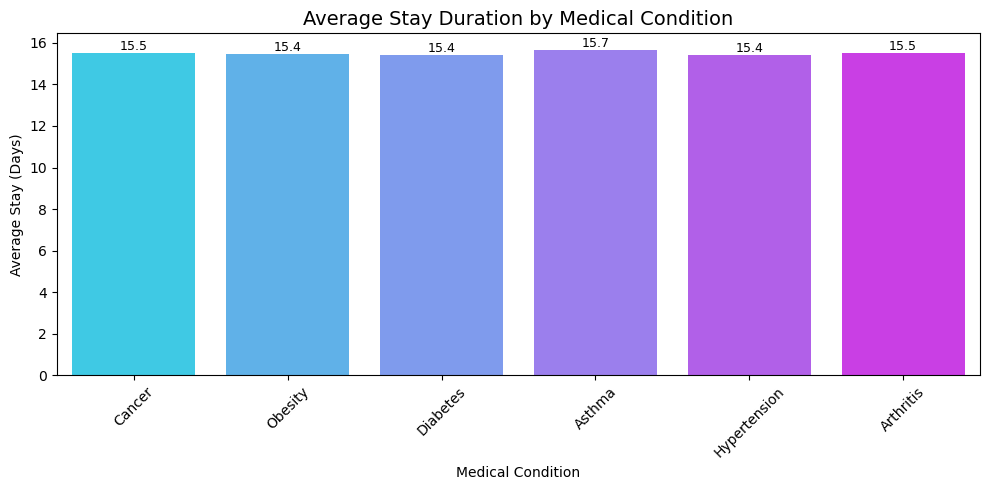

In [76]:
avg_stay = df1.groupby('Medical Condition')['Stay Duration'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
ax = sns.barplot(
    data=df1,
    x='Medical Condition',
    y='Stay Duration',
    hue='Medical Condition',   
    palette='cool',
    errorbar=None,
    legend=False
)
plt.title("Average Stay Duration by Medical Condition", fontsize=14)
plt.xlabel("Medical Condition")
plt.ylabel("Average Stay (Days)")
plt.xticks(rotation=45)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', label_type='edge', fontsize=9)
plt.tight_layout()
plt.show()

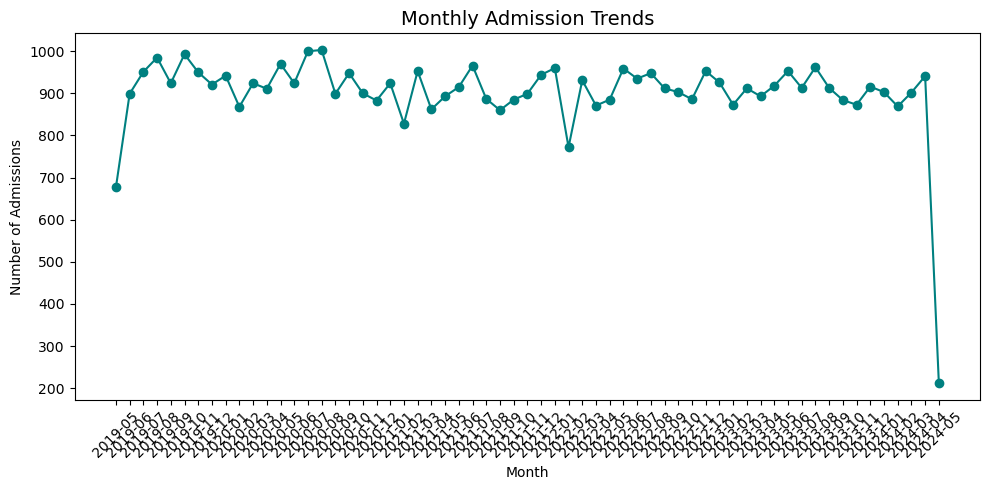

In [86]:
df1['Month'] = df1['Date of Admission'].dt.to_period('M')
monthly_trend = df1['Month'].value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.plot(monthly_trend.index.astype(str), monthly_trend.values, marker='o', color='teal')
plt.title("Monthly Admission Trends", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Number of Admissions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [88]:
df1.to_csv("cleaned_hospital_data.csv", index=False)
